In [221]:
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt

from scipy.stats import linregress

In [222]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

In [223]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [224]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [225]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [226]:
nav["date"] = pd.to_datetime(nav["date"])

In [227]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [228]:
nav = nav.sort_values(
    ["amfi_code", "date"]
).reset_index(drop=True)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [229]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

In [230]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [231]:
returns = nav.dropna(subset=["daily_return"]).copy()

returns.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [232]:
returns["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

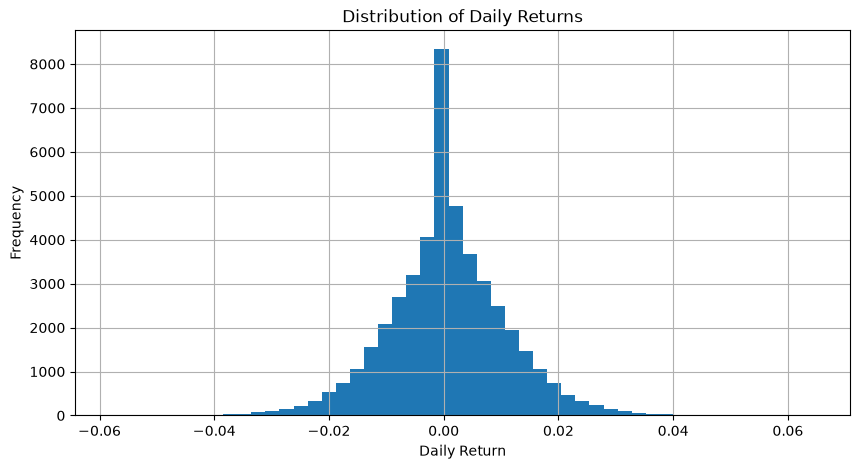

In [233]:
plt.figure(figsize=(10,5))

plt.hist(returns["daily_return"], bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [234]:
returns.to_csv(
    "../data/processed/03_nav_returns.csv",
    index=False
)

In [235]:
def calculate_cagr(df, years):
    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    temp = df[df["date"] >= start_date]

    if len(temp) < 2:
        return np.nan

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    return (end_nav / start_nav) ** (1 / years) - 1

In [236]:
cagr_results = []

for code, group in nav.groupby("amfi_code"):
    cagr_results.append({
        "amfi_code": code,
        "CAGR_1Y": calculate_cagr(group, 1),
        "CAGR_3Y": calculate_cagr(group, 3),
        "CAGR_5Y": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

In [237]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [238]:
cagr_df.to_csv("../reports/cagr_comparison.csv", index=False)

In [239]:
rf = 0.065          # Annual risk-free rate
daily_rf = rf / 252

In [240]:
def sharpe_ratio(returns):
    excess_returns = returns - daily_rf

    if returns.std() == 0:
        return np.nan

    return (excess_returns.mean() / returns.std()) * np.sqrt(252)

In [241]:
sharpe_df = (
    returns.groupby("amfi_code")["daily_return"]
           .apply(sharpe_ratio)
           .reset_index(name="Sharpe_Ratio")
)

In [242]:
sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

In [243]:
sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [244]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

In [245]:
def sortino_ratio(returns):
    excess_returns = returns - daily_rf

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        return np.nan

    downside_std = downside_returns.std()

    if downside_std == 0:
        return np.nan

    return (excess_returns.mean() / downside_std) * np.sqrt(252)

In [246]:
sortino_df = (
    returns.groupby("amfi_code")["daily_return"]
    .apply(sortino_ratio)
    .reset_index(name="Sortino_Ratio")
)

In [247]:
sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

In [248]:
sortino_df.head()

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [249]:
sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

In [250]:
def max_drawdown(nav_series):
    running_max = nav_series.cummax()
    drawdown = (nav_series / running_max) - 1
    return drawdown.min()

In [251]:
mdd_df = (
    nav.groupby("amfi_code")["nav"]
       .apply(max_drawdown)
       .reset_index(name="Max_Drawdown")
)

In [252]:
mdd_df = mdd_df.sort_values(
    by="Max_Drawdown",
    ascending=False
)

In [253]:
mdd_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

In [254]:
from scipy.stats import linregress

In [255]:
alpha_beta = []

for code, group in merged.groupby("amfi_code"):

    slope, intercept, r_value, p_value, std_err = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": code,
        "Alpha": intercept * 252,
        "Beta": slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

In [256]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [257]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

In [258]:
scorecard = cagr_df.merge(sharpe_df, on="amfi_code")

scorecard = scorecard.merge(alpha_beta_df, on="amfi_code")

scorecard = scorecard.merge(mdd_df, on="amfi_code")

scorecard = scorecard.merge(
    fund_master[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,expense_ratio_pct
0,100016,-0.022243,0.012926,0.023168,-0.201517,0.037476,-0.058268,-0.247344,1.55
1,100025,0.037050,0.039164,0.039127,-0.567095,0.042818,0.001158,-0.043083,0.56
2,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,1.38
3,101206,0.479241,0.289677,0.204427,1.027213,0.213998,0.021086,-0.112916,1.60
4,101207,-0.239860,-0.041524,0.069533,0.162661,0.108971,-0.065289,-0.354469,1.53


In [259]:
scorecard["ReturnRank"] = scorecard["CAGR_3Y"].rank(pct=True)

scorecard["SharpeRank"] = scorecard["Sharpe_Ratio"].rank(pct=True)

scorecard["AlphaRank"] = scorecard["Alpha"].rank(pct=True)

scorecard["ExpenseRank"] = scorecard["expense_ratio_pct"].rank(
    pct=True,
    ascending=False
)

scorecard["DrawdownRank"] = scorecard["Max_Drawdown"].rank(
    pct=True,
    ascending=False
)

In [260]:
scorecard["FundScore"] = (
    30 * scorecard["ReturnRank"] +
    25 * scorecard["SharpeRank"] +
    20 * scorecard["AlphaRank"] +
    15 * scorecard["ExpenseRank"] +
    10 * scorecard["DrawdownRank"]
)

In [261]:
scorecard = scorecard.sort_values(
    "FundScore",
    ascending=False
)

In [262]:
scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,expense_ratio_pct,ReturnRank,SharpeRank,AlphaRank,ExpenseRank,DrawdownRank,FundScore
25,120505,0.296047,0.317775,0.283768,1.180101,0.292636,0.000549,-0.181885,1.36,0.900,0.900,0.950,0.6500,0.625,84.5000
16,119094,0.222611,0.351118,0.244453,0.998231,0.260767,-0.066265,-0.209609,1.38,1.000,0.750,0.800,0.6000,0.700,80.7500
2,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,1.38,0.925,0.850,0.875,0.6000,0.500,80.5000
34,148567,0.203607,0.340009,0.267993,1.448291,0.269838,0.023684,-0.112657,1.46,0.975,1.000,0.850,0.4500,0.200,80.0000
30,120843,0.266571,0.295828,0.267425,1.306744,0.273305,-0.022830,-0.129740,1.45,0.850,0.975,0.900,0.4750,0.325,78.2500
24,120504,0.130643,0.324874,0.202340,1.026524,0.211948,0.016232,-0.125883,0.80,0.950,0.775,0.700,0.7250,0.300,75.7500
21,119598,0.827761,0.266699,0.280332,0.945308,0.303370,-0.023196,-0.287060,1.43,0.725,0.675,1.000,0.5000,0.900,75.1250
39,149324,0.651387,0.270004,0.279174,0.949796,0.300579,0.011455,-0.311719,1.52,0.775,0.700,0.975,0.3625,0.925,74.9375
36,148569,0.397518,0.291789,0.276299,1.234930,0.282704,0.018134,-0.163967,1.60,0.825,0.950,0.925,0.1125,0.525,73.9375
19,119551,0.604373,0.304565,0.223849,1.208267,0.232010,-0.031751,-0.150124,1.54,0.875,0.925,0.775,0.2625,0.425,73.0625


In [263]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [264]:
tracking_error = []

for code, group in merged.groupby("amfi_code"):

    te = np.std(
        group["daily_return"] - group["benchmark_return"]
    ) * np.sqrt(252)

    tracking_error.append({
        "amfi_code": code,
        "Tracking_Error": te
    })

tracking_error_df = pd.DataFrame(tracking_error)

In [265]:
tracking_error_df.head()

,amfi_code,Tracking_Error
0,100016,0.199197
1,100025,0.134477
2,100033,0.228600
3,101206,0.192623
4,101207,0.291990


In [266]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

In [267]:
top5_nav = nav[nav["amfi_code"].isin(top5)].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
2300,100033,2022-01-03,107.3758,NaN
2301,100033,2022-01-04,105.9447,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386
2303,100033,2022-01-06,104.9350,-0.005167
2304,100033,2022-01-07,104.3318,-0.005748


In [268]:
end_date = top5_nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

top5_nav = top5_nav[top5_nav["date"] >= start_date]

In [269]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark3 = benchmark[benchmark["date"] >= start_date].copy()

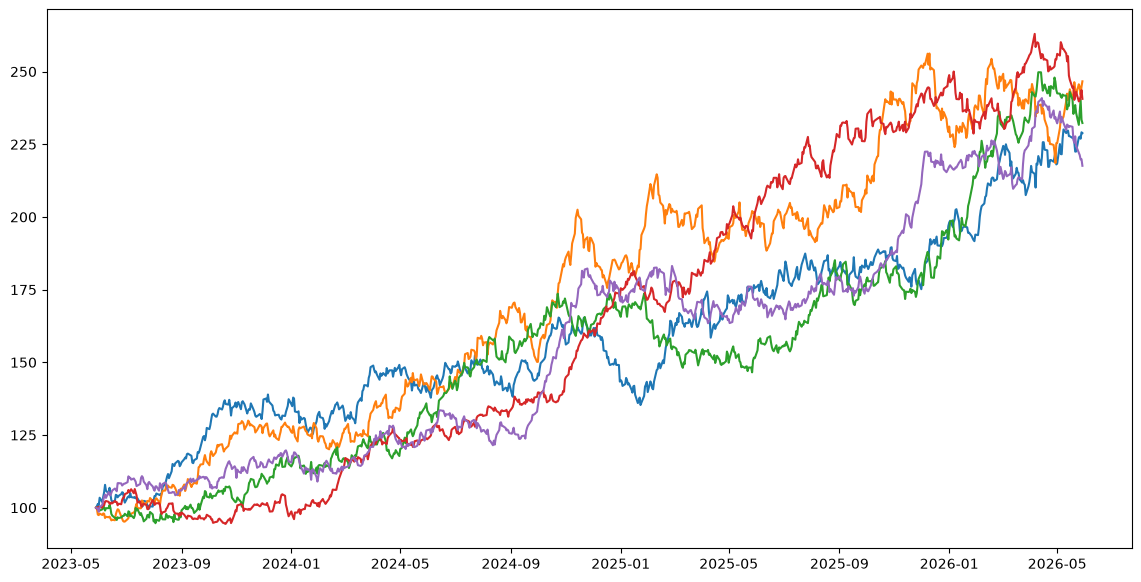

In [270]:
plt.figure(figsize=(14,7))

for code in top5:
    temp = top5_nav[top5_nav["amfi_code"] == code].copy()

    temp["normalized"] = (
        temp["nav"] / temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=f"Fund {code}"
    )

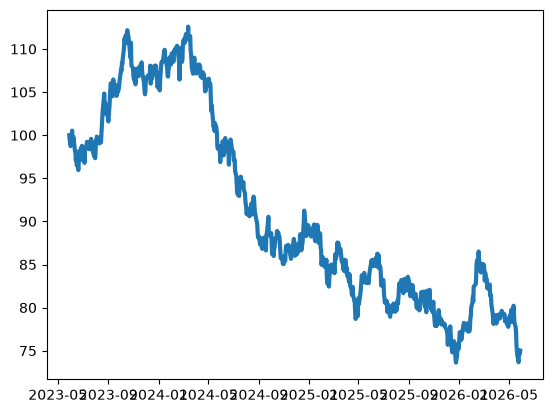

In [271]:
nifty50 = benchmark3[
    benchmark3["index_name"] == "NIFTY50"
].copy()

nifty50["normalized"] = (
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY50"
)

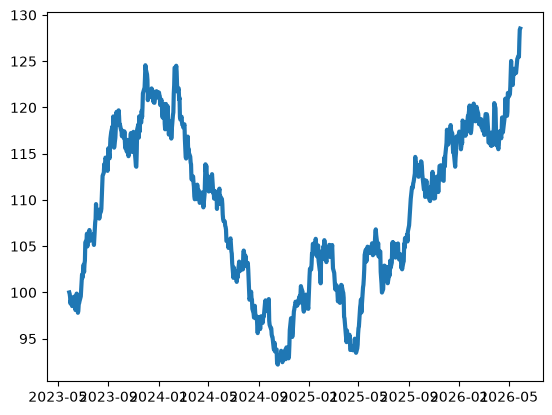

In [272]:
nifty100 = benchmark3[
    benchmark3["index_name"] == "NIFTY100"
].copy()

nifty100["normalized"] = (
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    label="NIFTY100"
)

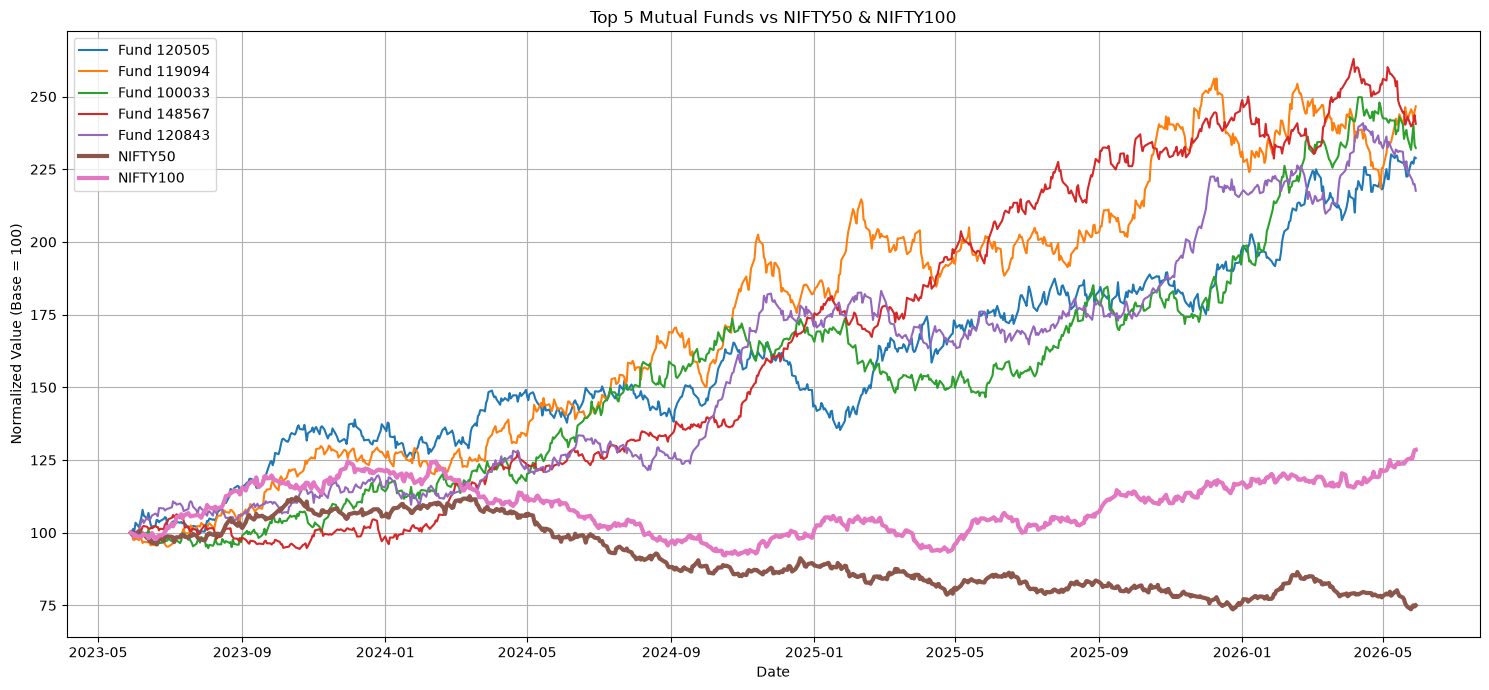

In [273]:
plt.figure(figsize=(15,7))

# Plot Top 5 Funds
for code in top5:

    temp = top5_nav[top5_nav["amfi_code"] == code].copy()

    temp = temp.sort_values("date")

    temp["normalized"] = (
        temp["nav"] / temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=f"Fund {code}"
    )

# Plot NIFTY50
nifty50_plot = benchmark3[
    benchmark3["index_name"] == "NIFTY50"
].copy()

nifty50_plot = nifty50_plot.sort_values("date")

nifty50_plot["normalized"] = (
    nifty50_plot["close_value"] /
    nifty50_plot["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50_plot["date"],
    nifty50_plot["normalized"],
    linewidth=3,
    label="NIFTY50"
)

# Plot NIFTY100
nifty100_plot = benchmark3[
    benchmark3["index_name"] == "NIFTY100"
].copy()

nifty100_plot = nifty100_plot.sort_values("date")

nifty100_plot["normalized"] = (
    nifty100_plot["close_value"] /
    nifty100_plot["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100_plot["date"],
    nifty100_plot["normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Mutual Funds vs NIFTY50 & NIFTY100")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.grid(True)
plt.legend()

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png", dpi=300)

plt.show()